In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, HashingVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import Normalizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')



[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/schoch/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
df = pd.read_csv('twitterSentimentAnalysis/twitter_training.csv')
df.columns=['ID','Keyword','Sentiment','Tweet']
df.tail()

,ID,Keyword,Sentiment,Tweet
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...
74680,9200,Nvidia,Positive,Just like the windows partition of my Mac is l...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74681 non-null  int64 
 1   Keyword    74681 non-null  object
 2   Sentiment  74681 non-null  object
 3   Tweet      73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [4]:
df.Sentiment.unique()

array(['Positive', 'Neutral', 'Negative', 'Irrelevant'], dtype=object)

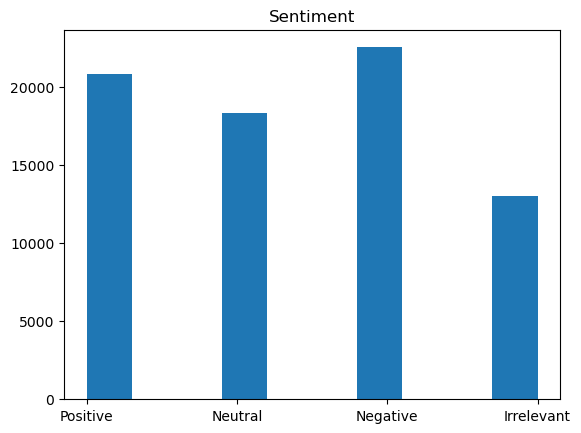

In [5]:
figure = plt.hist(df.Sentiment)
figure = plt.title('Sentiment')
plt.show()

In [6]:
# Series.str ermöglicht es auf die Werte der Series als Strings zuzugreifen und Stringoperationen anzuwenden
# lower(): Umwandlung in Kleinbuchstaben
df.Tweet = df.Tweet.str.lower()

# replace()
df.Tweet = df.Tweet.str.replace(r"https?://\S+|www\.\S+", "", regex=True) # URLs entfernen
df.Tweet = df.Tweet.str.replace(r"@\w+", "", regex=True) # @ Mentions entfernen
df.Tweet = df.Tweet.str.replace(r"[^\w\s]", "", regex=True) # alles entfernen, das nicht \w - alphanumerische Zeichen oder \s beliebiges Zeichen inkl. Tab und Space ist

In [7]:
df.tail()

,ID,Keyword,Sentiment,Tweet
74676,9200,Nvidia,Positive,just realized that the windows partition of my...
74677,9200,Nvidia,Positive,just realized that my mac window partition is ...
74678,9200,Nvidia,Positive,just realized the windows partition of my mac ...
74679,9200,Nvidia,Positive,just realized between the windows partition of...
74680,9200,Nvidia,Positive,just like the windows partition of my mac is l...


In [8]:
df.info()
df = df.dropna() # Zeilen mit fehlenden Werten löschen
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74681 non-null  int64 
 1   Keyword    74681 non-null  object
 2   Sentiment  74681 non-null  object
 3   Tweet      73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 73995 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         73995 non-null  int64 
 1   Keyword    73995 non-null  object
 2   Sentiment  73995 non-null  object
 3   Tweet      73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.8+ MB


## Kann bereits ein KNN Modell trainiert werden?

In [9]:
# Aufteilen des Datensatzes in Input- und Outputvariablen
X = df.Tweet # Input-Variablen: Tweet
y = df.Sentiment

# Aufteilen des Datensatzes in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Erstellen k-NN Klassifikators
knn = KNeighborsClassifier(n_neighbors=3, metric='hamming')  # k=3 als Beispiel, Hamming-Distanz als Abstandsmetrik für qualitative Variablen
# Fehlermeldung X muss float sein
# Modelltraining
knn.fit(X_train, y_train)

# Erstellen eines Gitternetzes von Punkten zum Plotten der Entscheidungsgrenzen
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Vorhersagen auf dem Gitternetz
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Erstellen der Plot
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=20, cmap=ListedColormap(['#FF0000', '#00FF00', '#0000FF']))
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('k-NN Klassifikation (k=3) mit Klassengrenzen')
plt.show()


ValueError: could not convert string to float: 'i had a dream my girlfriend and i got married and rthen we had to drive home only a fuckin runaway bus and a hippie dude and there was a montage of buses blocking all 3 lanes or me racing up hills with no road just fuckin blow thru shit up like it was grand theft auto'

## Wörter

In [10]:
# str.split um einzelne Wörter zu extrahieren
# default separator: whitespace
df["words"] = df["Tweet"].str.split() 
df.head()


,ID,Keyword,Sentiment,Tweet,words
0,2401,Borderlands,Positive,i am coming to the borders and i will kill you...,"[i, am, coming, to, the, borders, and, i, will..."
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you all,"[im, getting, on, borderlands, and, i, will, k..."
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,"[im, coming, on, borderlands, and, i, will, mu..."
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,"[im, getting, on, borderlands, 2, and, i, will..."
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,"[im, getting, into, borderlands, and, i, can, ..."


## Wortfrequenzanalyse

In [11]:
# Alle Worte aus allen Zeilen zu einer einzigen Liste zusammenführen
word_list = np.concatenate(df["words"].values)
print("Anzahl Worte: ", len(word_list))

# Worte abzählen
word_counts = pd.Series(word_list).value_counts()
word_counts = word_counts.reset_index()
word_counts.columns = ["word", "count"]
print("|V|=", len(word_counts.word))

# Häufigste Wörter:
word_counts.head()

Anzahl Worte:  1343424
|V|= 39772


,word,count
0,the,44445
1,i,29190
2,to,28830
3,and,26590
4,a,24109


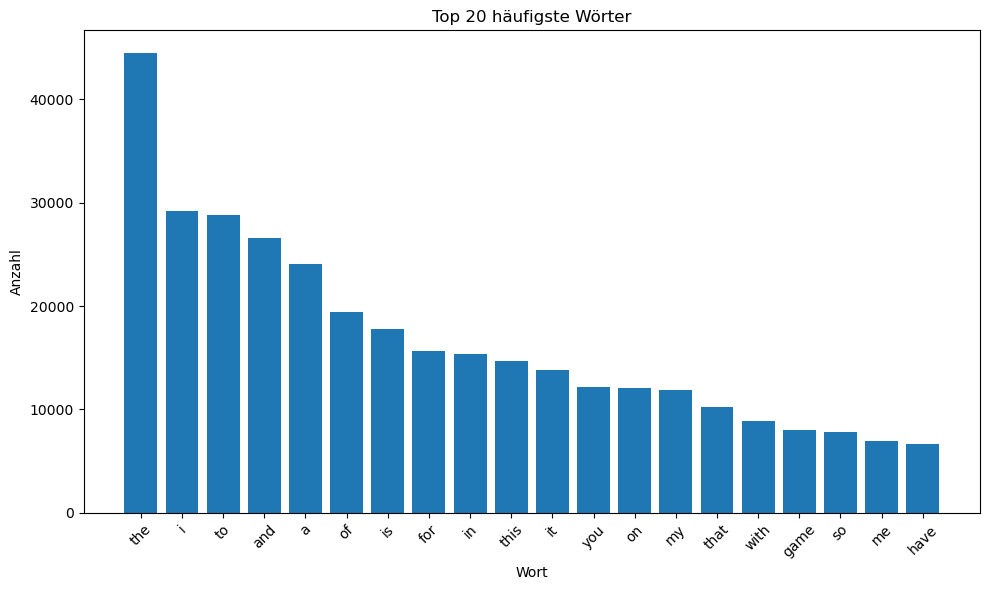

In [12]:
# Barchart Top 20 Wörter
top_n = 20
top_words = word_counts.head(top_n)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(top_words["word"], top_words["count"])
plt.title(f"Top {top_n} häufigste Wörter")
plt.xlabel("Wort")
plt.ylabel("Anzahl")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Stop Words entfernen

In [13]:
stop_words = set(stopwords.words("english"))
print(stop_words)

pattern = r"\b(" + "|".join(stop_words) + r")\b" # regex für stop words
df.Tweet = df.Tweet.str.replace(pattern, "", regex=True) # Stopwords entfernen

df.head()


{'just', 'above', 'both', 'y', 'now', 'no', "i've", 'couldn', 'needn', 'between', 'an', 'myself', "we'd", "needn't", 'm', 'our', 'should', "you're", "wasn't", 'as', 'o', "couldn't", 'been', "she'll", 'because', "he'd", "she's", 'ma', "we'll", 'each', 'other', 'do', 'haven', "they're", 'after', 'during', 'hasn', 'in', 'than', "aren't", "haven't", 'which', "she'd", 'what', 'ourselves', 'its', "they'll", "it's", 'mightn', 'weren', 're', "hasn't", 'yourself', 'so', 'and', "mightn't", 'by', 'where', 'or', 'themselves', "didn't", 'was', 'who', "shan't", "it'll", 'there', 'for', 'ain', 'again', 'that', 'theirs', "we've", 'you', "wouldn't", 'has', 't', "doesn't", "he's", 'few', 'does', 'how', 'all', 'hadn', 'most', 'shouldn', 'while', "isn't", 've', 'with', 'll', 'is', 'once', "should've", 'them', 'their', 'herself', 'be', 'i', 'can', 'they', 'below', 'further', 'own', 'at', 'don', 'your', 'd', 'only', 'to', 'until', 'were', 'himself', 'being', "we're", 'aren', 'yourselves', "he'll", "shouldn'

,ID,Keyword,Sentiment,Tweet,words
0,2401,Borderlands,Positive,coming borders kill,"[i, am, coming, to, the, borders, and, i, will..."
1,2401,Borderlands,Positive,im getting borderlands kill,"[im, getting, on, borderlands, and, i, will, k..."
2,2401,Borderlands,Positive,im coming borderlands murder,"[im, coming, on, borderlands, and, i, will, mu..."
3,2401,Borderlands,Positive,im getting borderlands 2 murder,"[im, getting, on, borderlands, 2, and, i, will..."
4,2401,Borderlands,Positive,im getting borderlands murder,"[im, getting, into, borderlands, and, i, can, ..."


### Neue Wortfrequenzanalyse

In [14]:
# str.split um einzelne Wörter zu extrahieren
# default separator: whitespace
df["words"] = df["Tweet"].str.split() 
df.head()

,ID,Keyword,Sentiment,Tweet,words
0,2401,Borderlands,Positive,coming borders kill,"[coming, borders, kill]"
1,2401,Borderlands,Positive,im getting borderlands kill,"[im, getting, borderlands, kill]"
2,2401,Borderlands,Positive,im coming borderlands murder,"[im, coming, borderlands, murder]"
3,2401,Borderlands,Positive,im getting borderlands 2 murder,"[im, getting, borderlands, 2, murder]"
4,2401,Borderlands,Positive,im getting borderlands murder,"[im, getting, borderlands, murder]"


Anzahl Worte:  808384
|V|= 39623


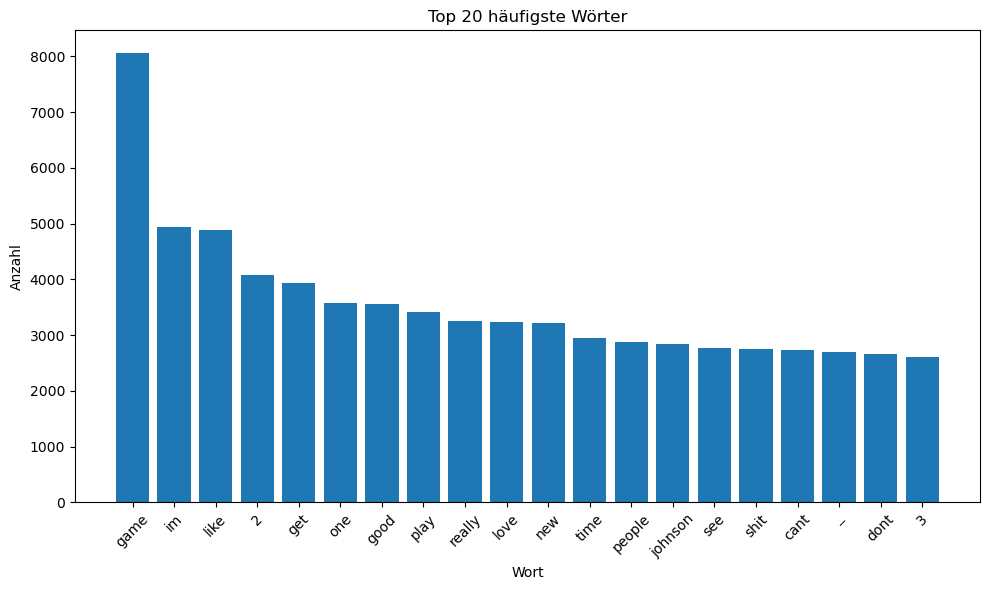

In [15]:
# Alle Worte aus allen Zeilen zu einer Liste zusammenführen
word_list = np.concatenate(df["words"].values)
print("Anzahl Worte: ", len(word_list))

# Worte abzählen
word_counts = pd.Series(word_list).value_counts()
word_counts = word_counts.reset_index()
word_counts.columns = ["word", "count"]
print("|V|=", len(word_counts.word))

# Häufigste Wörter:
word_counts.head()

# Barchart Top 20 Wörter
top_n = 20
top_words = word_counts.head(top_n)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(top_words["word"], top_words["count"])
plt.title(f"Top {top_n} häufigste Wörter")
plt.xlabel("Wort")
plt.ylabel("Anzahl")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Byte Pair Encoding




Beispiel encoded:  ['like', 'windows', 'partition', 'mac', 'like', '6', 'years', 'behind', 'drivers', 'idea', 'didnt', 'notice']
Anzahl Token:  24180


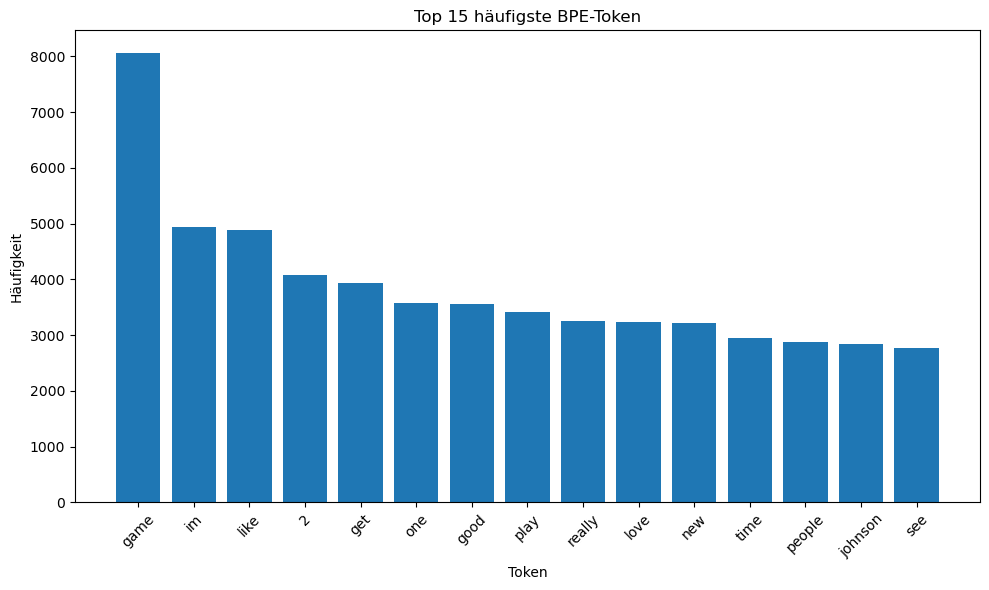

In [37]:
tokenizer = Tokenizer(BPE())
tokenizer.pre_tokenizer = Whitespace() # zunächst Trennung durch Leerzeichen
trainer = BpeTrainer(vocab_size=300000) # k=3000

# Liste mit Texten
tokenizer.train_from_iterator(df.Tweet, trainer) # tokenizer.train_from_iterator(iterator, trainer) - iteriere über die Tweets und verwende BPE als Trainer

# Text tokenisieren und Token zählen
all_tokens = []
for sentence in df.Tweet: # iteriere durch jede Zeile der Tweets, sentence1 = erste Zeile in df.Tweet
    encoded = tokenizer.encode(sentence) # Elemente des sentence werden Tokenisiert
    all_tokens.extend(encoded.tokens) # .extend() fügt Elemente an das Ende einer Liste an

print("Beispiel encoded: ", encoded.tokens)

print('Anzahl eindeutige Token: ', len(np.unique(token_series)))

# Häufigkeiten 
token_series = pd.Series(all_tokens) # umwandeln der Liste als Pandas Series
token_freq = token_series.value_counts()  # zählt Token
top_n = 15
top_tokens = token_freq.head(top_n)

# Barplot mit matplotlib
plt.figure(figsize=(10, 6))
plt.bar(top_tokens.index, top_tokens.values)
plt.title(f"Top {top_n} häufigste BPE-Token")
plt.xlabel("Token")
plt.ylabel("Häufigkeit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
df.tail()

,ID,Keyword,Sentiment,Tweet,words
74676,9200,Nvidia,Positive,realized windows partition mac like 6 ye...,"[realized, windows, partition, mac, like, 6, y..."
74677,9200,Nvidia,Positive,realized mac window partition 6 years behi...,"[realized, mac, window, partition, 6, years, b..."
74678,9200,Nvidia,Positive,realized windows partition mac 6 years b...,"[realized, windows, partition, mac, 6, years, ..."
74679,9200,Nvidia,Positive,realized windows partition mac like 6 y...,"[realized, windows, partition, mac, like, 6, y..."
74680,9200,Nvidia,Positive,like windows partition mac like 6 years b...,"[like, windows, partition, mac, like, 6, years..."


In [35]:
print(token_series[token_series.str.contains('gam')])
len(token_series[token_series.str.contains('gam')])



1198              game
1224              game
1249              game
1276              game
1304              game
              ...     
868931          gaming
868952          gaming
868968          gaming
869840    fortnitegame
869853     fennitegame
Length: 13559, dtype: object


24180